# Mahalanobis Distance

**Understanding Covariance, Geometric Interpretation, and Bayesian Decision Theory**

In this tutorial, we will explore the **covariance matrix**, its geometric interpretation, and its critical role in **Bayesian Decision Theory**, particularly in the context of the **Mahalanobis Distance**. We will derive the mathematical properties of these concepts and illustrate them with Python code and visualizations.

*Resources:* Adapted from [Vision Dummy](https://www.visiondummy.com/2014/04/geometric-interpretation-covariance-matrix/), [SAS Blogs](https://blogs.sas.com/content/iml/2012/02/15/what-is-mahalanobis-distance.html), [Wikipedia](https://en.wikipedia.org/wiki/Mahalanobis_distance), and Chapter 2 of *Pattern Classification* by Duda, Hart, and Stork {cite}`Duda2000`.

---

## 1. Why Do We Need Mahalanobis Distance?

In many real-world applications, we deal with **multivariate data** where features are often correlated and have different scales. While the **Euclidean distance** ($\|\mathbf{x} - \mathbf{y}\|_2$) is a common choice for measuring distances, it has a significant limitation: it assumes that all features are **uncorrelated** and have the **same variance**. This assumption rarely holds in practice.

Consider a dataset where one feature is measured in meters and another in kilometers. Euclidean distance would disproportionately weigh the feature with larger values. Similarly, if features are correlated, the "shape" of the data distribution is an ellipsoid rather than a sphere. Euclidean distance fails to account for this underlying structure, leading to misleading results in classification and clustering.

The **Mahalanobis distance** solves this by measuring the distance between a point and a distribution, normalized by the variance of each feature and the correlations between them.

### Illustrative Example: Euclidean vs. Mahalanobis Distance

Let’s visualize this using a 2D Gaussian distribution with high correlation.


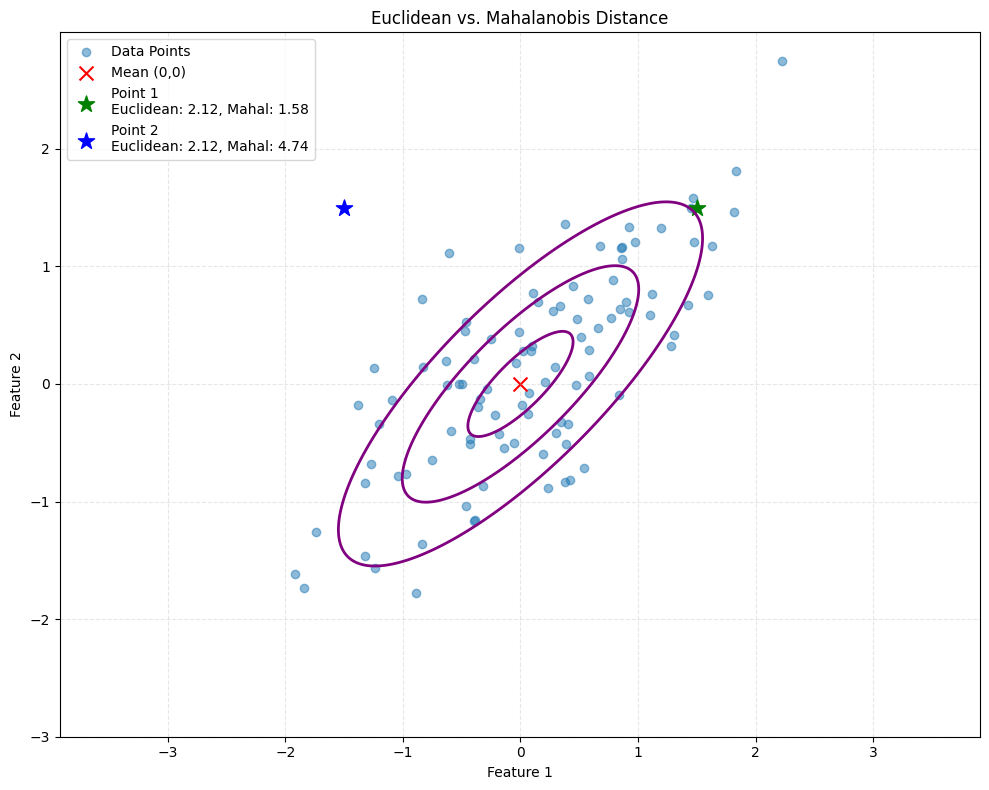

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import mahalanobis
from scipy.stats import multivariate_normal

# Set random seed for reproducibility
np.random.seed(42)

# Generate 2D Gaussian random points with high correlation
mean = [0, 0]
cov = [[1, 0.8], [0.8, 1]]  # Covariance matrix
points = np.random.multivariate_normal(mean, cov, 100)

# Select two points with the same Euclidean distance to the center but different locations
# Point 1 is along the direction of high variance
# Point 2 is along the direction of low variance
point1 = np.array([1.5, 1.5])
point2 = np.array([-1.5, 1.5])

# Compute Euclidean distances
center = np.array(mean)
euclidean_dist1 = np.linalg.norm(point1 - center)
euclidean_dist2 = np.linalg.norm(point2 - center)

# Compute Mahalanobis distances
inv_cov = np.linalg.inv(cov)
mahalanobis_dist1 = mahalanobis(point1, center, inv_cov)
mahalanobis_dist2 = mahalanobis(point2, center, inv_cov)

# Plot the data and points
plt.figure(figsize=(10, 8))
plt.scatter(points[:, 0], points[:, 1], alpha=0.5, label='Data Points')
plt.scatter(center[0], center[1], color='red', marker='x', s=100, label='Mean (0,0)')

# Highlight the two comparison points
plt.scatter(point1[0], point1[1], color='green', marker='*', s=150, 
            label=f'Point 1\nEuclidean: {euclidean_dist1:.2f}, Mahal: {mahalanobis_dist1:.2f}')
plt.scatter(point2[0], point2[1], color='blue', marker='*', s=150, 
            label=f'Point 2\nEuclidean: {euclidean_dist2:.2f}, Mahal: {mahalanobis_dist2:.2f}')

# Plot the probability contours
x, y = np.mgrid[-3:3:.01, -3:3:.01]
pos = np.dstack((x, y))
rv = multivariate_normal(mean, cov)
plt.contour(x, y, rv.pdf(pos), levels=3, colors='purple', linewidths=2)

plt.legend()
plt.title('Euclidean vs. Mahalanobis Distance')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()


*Observation:* Point 1 and Point 2 have the same Euclidean distance from the center, yet they lie in different "probability regions." Point 2 is in a direction of lower variance (orthogonal to the main correlation), making it statistically less likely (further in Mahalanobis distance) than Point 1.

---

## 2. Introduction to Covariance Matrix

The **covariance matrix** is a square matrix that summarizes the variances and covariances of a set of random variables. For a dataset with $d$ features, the covariance matrix $\boldsymbol{\Sigma}$ is a $d \times d$ matrix defined as:

$$
\boldsymbol{\Sigma} = \begin{bmatrix}
\sigma_{11} & \sigma_{12} & \cdots & \sigma_{1d} \\
\sigma_{21} & \sigma_{22} & \cdots & \sigma_{2d} \\
\vdots & \vdots & \ddots & \vdots \\
\sigma_{d1} & \sigma_{d2} & \cdots & \sigma_{dd}
\end{bmatrix}
$$

Where:
*   $\sigma_{ii} = \operatorname{Var}(x_i)$: The variance of the $i$-th feature (diagonal elements).
*   $\sigma_{ij} = \operatorname{Cov}(x_i, x_j)$: The covariance between the $i$-th and $j$-th features (off-diagonal elements).

**Properties:**
1.  **Symmetric:** $\sigma_{ij} = \sigma_{ji}$, so $\boldsymbol{\Sigma} = \boldsymbol{\Sigma}^{\top}$.
2.  **Positive Semi-Definite:** All eigenvalues are non-negative ($\lambda_i \geq 0$).

---

## 3. Geometric Interpretation of Covariance Matrix

The covariance matrix defines the **shape** and **orientation** of the data distribution in the feature space.

1.  **Eigenvectors (Directions):** The eigenvectors of $\boldsymbol{\Sigma}$ represent the principal axes of the data distribution. They indicate the directions of maximum variance.
2.  **Eigenvalues (Magnitudes):** The corresponding eigenvalues represent the magnitude of variance along these eigenvector directions.
3.  **Ellipsoid:** In 2D, the covariance matrix defines an ellipse. In $d$-dimensions, it defines a hyper-ellipsoid. The axes of this ellipsoid are aligned with the eigenvectors, and the lengths of the axes are proportional to the square roots of the eigenvalues.

---

## 4. Linear Transformations and Covariance

To fully understand Mahalanobis distance and whitening, we must understand how covariance changes under linear transformations. This section provides the mathematical foundation for transforming data to a "whitened" space.

### Proof: Covariance of a Linearly Transformed Vector

Let $\mathbf{x}$ be a random vector with mean $\boldsymbol{\mu} = \mathbb{E}[\mathbf{x}]$. Consider a linear transformation defined by a matrix $W$. We define a new random vector $\mathbf{y}$ as:

$$
\mathbf{y} = W^{\!\top}\bigl(\mathbf{x} - \boldsymbol{\mu}\bigr), \qquad \mathbf{x}\in\mathbb{R}^{d},\; W\in\mathbb{R}^{d\times d}.
$$

The (population) covariance of a random vector $\mathbf{z}$ is:

$$
\operatorname{Cov}(\mathbf{z}) = \mathbb{E}\Big[(\mathbf{z} - \mathbb{E}[\mathbf{z}])(\mathbf{z} - \mathbb{E}[\mathbf{z}])^{\!\top}\Big].
$$

**1. Mean of $\mathbf{y}$**

$$
\begin{aligned}
\mathbb{E}[\mathbf{y}]
 &= \mathbb{E}\bigl[W^{\!\top}(\mathbf{x} - \boldsymbol{\mu})\bigr] \\
 &= W^{\!\top}\bigl(\mathbb{E}[\mathbf{x}] - \boldsymbol{\mu}\bigr) \\
 &= W^{\!\top}\bigl(\boldsymbol{\mu} - \boldsymbol{\mu}\bigr) \\
 &= \mathbf{0}.
\end{aligned}
$$

Hence, $\mathbf{y}$ is zero-mean, and $\mathbf{y} - \mathbb{E}[\mathbf{y}] = \mathbf{y}$.

**2. Covariance of $\mathbf{y}$**

$$
\begin{aligned}
\operatorname{Cov}(\mathbf{y})
 &= \mathbb{E}\bigl[\mathbf{y}\,\mathbf{y}^{\!\top}\bigr] \quad (\text{since } \mathbb{E}[\mathbf{y}]=\mathbf{0}) \\
 &= \mathbb{E}\Big[W^{\!\top}(\mathbf{x}-\boldsymbol{\mu})\,(\mathbf{x}-\boldsymbol{\mu})^{\!\top}W\Big] \\
 &\overset{\text{linearity}}{=}
   W^{\!\top}\;\mathbb{E}\Big[(\mathbf{x}-\boldsymbol{\mu})(\mathbf{x}-\boldsymbol{\mu})^{\!\top}\Big]\;W \\
 &= W^{\!\top}\,\operatorname{Cov}(\mathbf{x})\,W .
\end{aligned}
$$

**3. Result**

$$
\boxed{\operatorname{Cov}\bigl(W^{\!\top}(\mathbf{x}-\boldsymbol{\mu})\bigr) = W^{\!\top}\operatorname{Cov}(\mathbf{x})\,W}
$$

**Interpretation:**
A linear transformation $W^{\!\top}$ applied to a zero-mean vector $\mathbf{x}-\boldsymbol{\mu}$ produces a new vector whose covariance is obtained by "sandwiching" the old covariance between $W^{\!\top}$ and $W$. This property is fundamental to **whitening**, where we choose $W$ specifically so that the new covariance becomes the Identity matrix $\mathbf{I}$.

---



## 5. Covariance Matrix in Bayesian Decision Theory

In **Bayesian Decision Theory**, the covariance matrix is essential for defining the **class-conditional probability density functions (PDFs)**. For a multivariate normal distribution, the PDF for class $\omega_i$ is:

$$
p(\mathbf{x}|\omega_i) = \frac{1}{(2\pi)^{d/2}|\boldsymbol{\Sigma}_i|^{1/2}} \exp\left(-\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_i)^T \boldsymbol{\Sigma}_i^{-1} (\mathbf{x} - \boldsymbol{\mu}_i)\right)
$$

*   $\boldsymbol{\mu}_i$: Mean vector for class $\omega_i$.
*   $\boldsymbol{\Sigma}_i$: Covariance matrix for class $\omega_i$.

The term in the exponent is exactly half the **squared Mahalanobis distance**. The covariance matrix determines the "tightness" and orientation of the decision boundaries.

---

## 6. Mahalanobis Distance and Its Role

The **Mahalanobis distance** measures the distance between a point $\mathbf{x}$ and a distribution (characterized by mean $\boldsymbol{\mu}$ and covariance $\boldsymbol{\Sigma}$).

### Definition

$$
D_M(\mathbf{x}, \boldsymbol{\mu}) = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})}
$$

### Connection to Standardization (Z-Score)

To build intuition, compare this to the 1D Z-score:
$$ z = \frac{x - \mu}{\sigma} \implies z^2 = (x-\mu)\frac{1}{\sigma^2}(x-\mu) $$

*   **1D:** We normalize by $\sigma^2$ (variance).
*   **d-Dimensions:** We normalize by $\boldsymbol{\Sigma}$ (covariance matrix).

The inverse covariance matrix $\boldsymbol{\Sigma}^{-1}$ effectively:
1.  **Scales** features by their variance (normalizing units).
2.  **Rotates** the space to decorrelate features.

### Mahalanobis Distance Intuition

If the data distribution is a cloud of points shaped like an ellipsoid, Mahalanobis distance measures how many "standard deviations away" a point is, taking into account the stretching and rotation of that ellipsoid.

---


## 7. Whitening Transformation

**Whitening** is a preprocessing step that transforms data so that its covariance matrix becomes the Identity matrix ($\mathbf{I}$). This implies the transformed features are **uncorrelated** and have **unit variance**.

### Mathematical Formulation

We seek a transformation matrix $W$ such that if $\mathbf{y} = W^{\top}(\mathbf{x} - \boldsymbol{\mu})$, then $\operatorname{Cov}(\mathbf{y}) = \mathbf{I}$.

From the proof in Section 4:
$$ \operatorname{Cov}(\mathbf{y}) = W^{\!\top}\boldsymbol{\Sigma}W = \mathbf{I} $$

We can solve for $W$ using the **Eigen Decomposition** of $\boldsymbol{\Sigma}$. Let $\boldsymbol{\Sigma} = \Phi \Lambda \Phi^{\top}$, where:
*   $\Phi$ is the orthogonal matrix of eigenvectors.
*   $\Lambda$ is the diagonal matrix of eigenvalues.

We choose $W = \Phi \Lambda^{-1/2}$. Let's verify:
$$
\begin{aligned}
\operatorname{Cov}(\mathbf{y}) &= (\Phi \Lambda^{-1/2})^{\top} \boldsymbol{\Sigma} (\Phi \Lambda^{-1/2}) \\
&= \Lambda^{-1/2} \Phi^{\top} (\Phi \Lambda \Phi^{\top}) \Phi \Lambda^{-1/2} \\
&= \Lambda^{-1/2} (\Phi^{\top} \Phi) \Lambda (\Phi^{\top} \Phi) \Lambda^{-1/2} \\
&= \Lambda^{-1/2} (\mathbf{I}) \Lambda (\mathbf{I}) \Lambda^{-1/2} \\
&= \mathbf{I}.
\end{aligned}
$$

### Geometric Interpretation

1.  **Rotation ($\Phi^{\top}$):** Aligns the data with the principal axes.
2.  **Scaling ($\Lambda^{-1/2}$):** Stretches or compresses the data along these axes so that all axes have length 1 (unit variance).

**Result:** The data cloud becomes a perfect sphere (isotropic). In this whitened space, the **Euclidean distance is equivalent to the Mahalanobis distance** in the original space.

### Python Implementation: Whitening

Original Covariance:
[[1.  0.8]
 [0.8 1. ]]

Whitened Covariance (Should be close to Identity):
[[0.93109508 0.02608031]
 [0.02608031 0.91738083]]

Difference from Identity:
[[0.06890492 0.02608031]
 [0.02608031 0.08261917]]


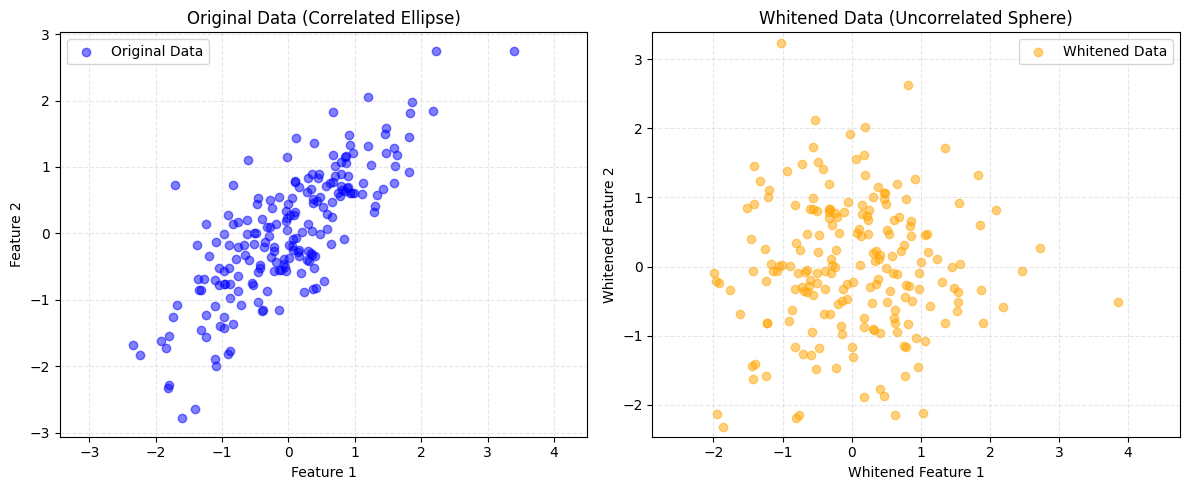

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
mean = np.array([0, 0])
cov = np.array([[1, 0.8], [0.8, 1]])
points = np.random.multivariate_normal(mean, cov, 200)

# 1. Decompose Covariance
eigenvals, eigenvecs = np.linalg.eigh(cov)

# 2. Construct Whitening Matrix W = Φ @ Λ^(-1/2)
D_inv_sqrt = np.diag(1.0 / np.sqrt(eigenvals))
W = eigenvecs @ D_inv_sqrt

# 3. Apply Whitening Transformation
# Formula: y = (x - μ) @ W  (equivalent to W^T @ (x - μ)^T, then transpose back)
whitened_points = (points - mean) @ W

# 4. Verify Covariance is ~Identity
whitened_cov = np.cov(whitened_points, rowvar=False)

print("Original Covariance:")
print(cov)
print("\nWhitened Covariance (Should be close to Identity):")
print(whitened_cov)
print("\nDifference from Identity:")
print(np.abs(whitened_cov - np.eye(2)))

# 5. Visualization
plt.figure(figsize=(12, 5))

# Original Data
plt.subplot(1, 2, 1)
plt.scatter(points[:, 0], points[:, 1], alpha=0.5, color='blue', label='Original Data')
plt.title('Original Data (Correlated Ellipse)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.axis('equal')
plt.legend()

# Whitened Data
plt.subplot(1, 2, 2)
plt.scatter(whitened_points[:, 0], whitened_points[:, 1], alpha=0.5, color='orange', label='Whitened Data')
plt.title('Whitened Data (Uncorrelated Sphere)')
plt.xlabel('Whitened Feature 1')
plt.ylabel('Whitened Feature 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.axis('equal')
plt.legend()

plt.tight_layout()
plt.show()



## 8. Conclusion

The **Mahalanobis distance** is the natural generalization of the Z-score to multivariate dimensions. By incorporating the covariance matrix, it provides a statistically valid measure of distance that accounts for feature scales and correlations. This makes it indispensable for:
*   **Anomaly Detection:** Identifying points that are statistically unlikely.
*   **Classification:** Bayesian decision boundaries rely on this distance metric.
*   **Preprocessing:** Whitening transforms data to simplify downstream algorithms (e.g., PCA, Neural Networks).

---

## 9. Key Takeaways

*   **Euclidean Distance** assumes spherical data; **Mahalanobis Distance** assumes elliptical data.
*   The **Covariance Matrix** $\boldsymbol{\Sigma}$ captures the shape, scale, and orientation of the data distribution.
*   **Whitening** transforms $\boldsymbol{\Sigma}$ to $\mathbf{I}$, effectively "spherifying" the data cloud.
*   **Linear Transformation Property:** If $\mathbf{y} = W^{\top}(\mathbf{x}-\boldsymbol{\mu})$, then $\operatorname{Cov}(\mathbf{y}) = W^{\top}\boldsymbol{\Sigma}W$.
*   In the **Whitened Space**, Euclidean distance equals Mahalanobis distance.

---

## References

{cite}`Duda2000`

Duda, R. O., Hart, P. E., & Stork, D. G. (2000). *Pattern Classification* (2nd ed.). Wiley-Interscience.